# Model Training Results (train_text_classification_bert.py)

In [1]:
from IPython.display import Image, display

In [2]:
with open("./outputs/train_img_classification_resnet/log.log", "r") as f:
    lines = f.readlines()
print(*lines[-46:-2])

              precision    recall  f1-score   support
 
            0       0.87      0.92      0.89        49
            1       0.77      0.94      0.85        50
            2       0.80      0.64      0.71        50
            3       0.96      0.96      0.96        50
            4       0.94      0.94      0.94        50
            5       0.75      0.92      0.83        50
            6       0.84      0.94      0.89        50
            7       0.84      0.98      0.91        44
            8       0.88      0.90      0.89        50
            9       0.95      0.80      0.87        50
           10       0.87      0.92      0.89        50
           11       0.95      0.85      0.90        48
           12       0.96      0.96      0.96        50
           13       0.98      0.94      0.96        50
           14       0.96      1.00      0.98        50
           15       1.00      0.98      0.99        50
           16       0.96      1.00      0.98        50
         

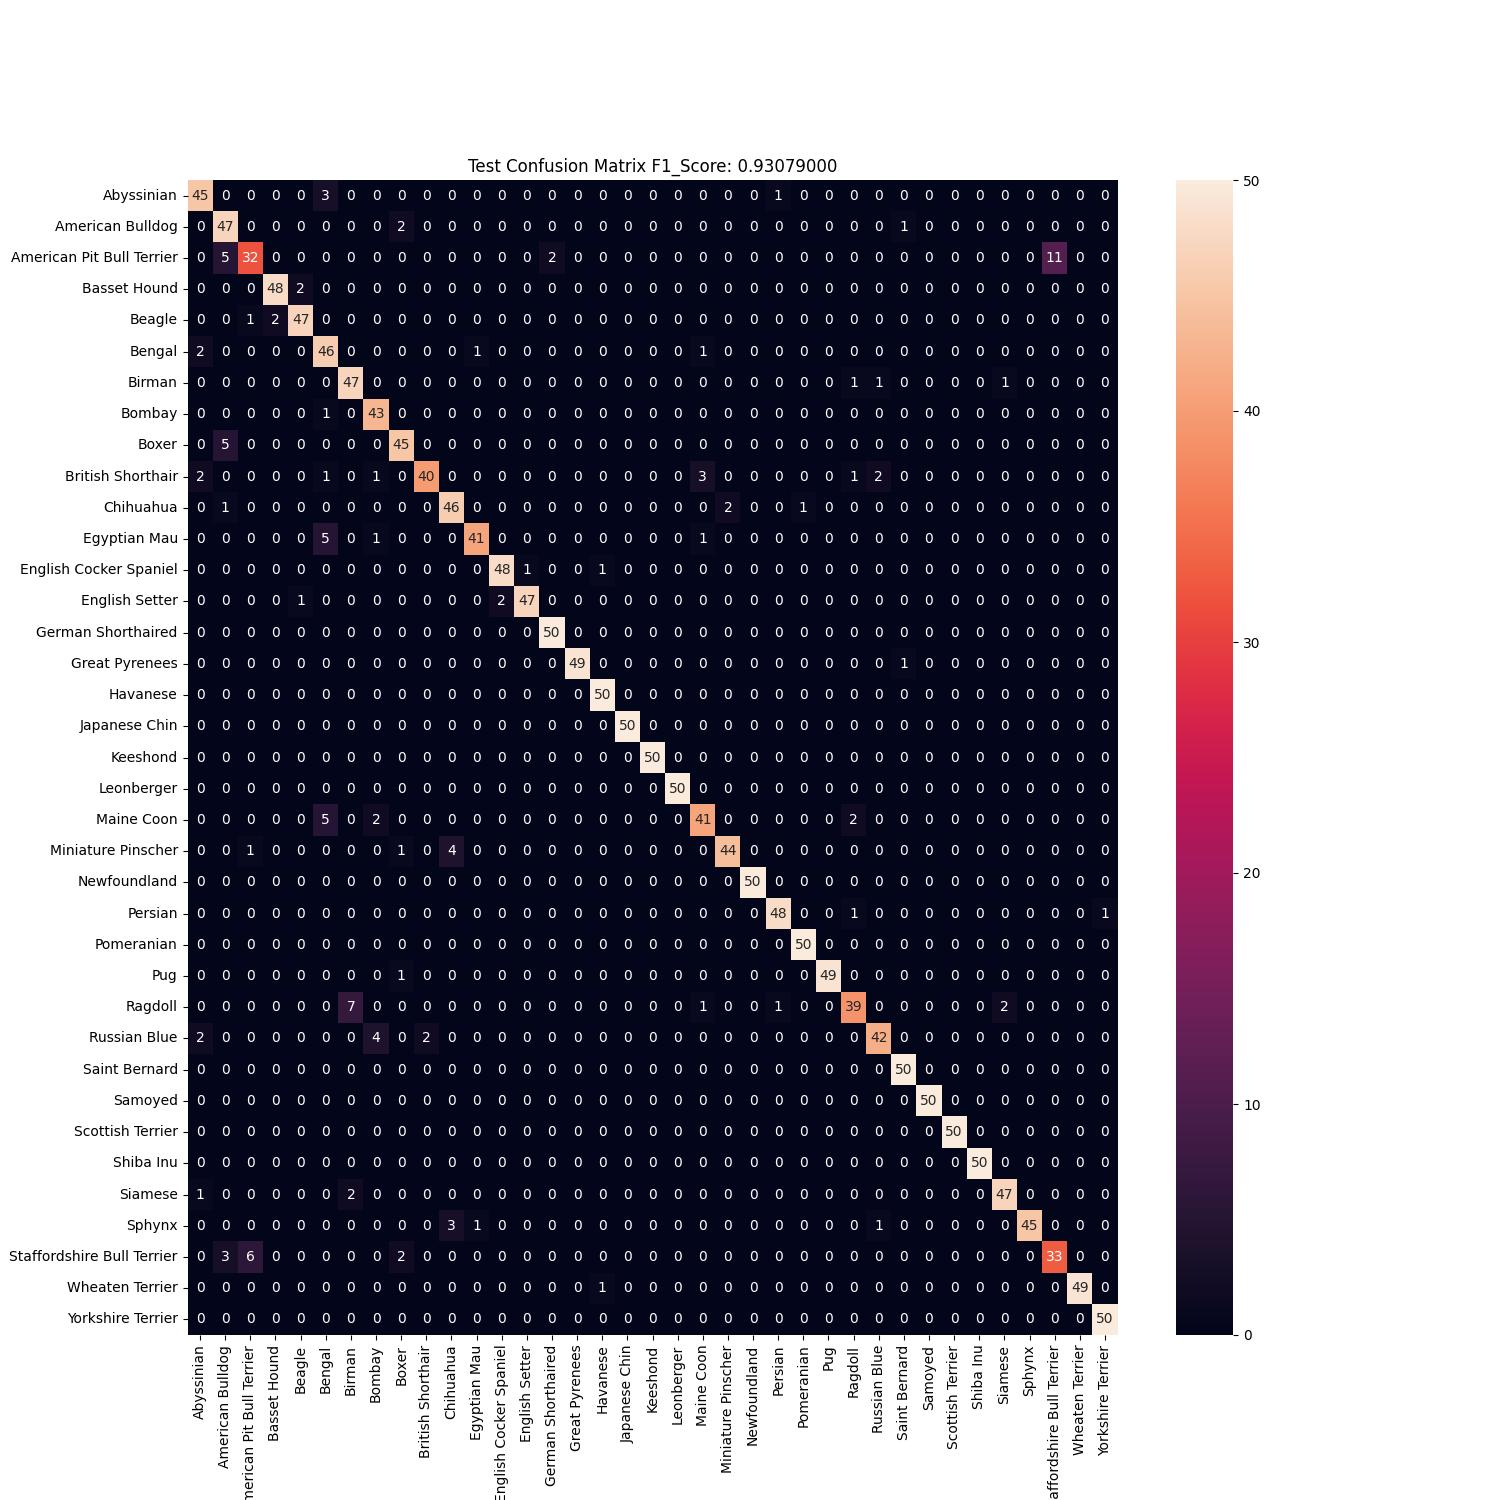

In [3]:
display(Image("./outputs/train_img_classification_resnet/best_model.jpg"))

### Image
* GradCam

In [4]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '5'
import gc
import random
from pathlib import Path

import numpy as np
import pickle as pkl
from tqdm import tqdm

import torch
from torch.utils.data import TensorDataset, DataLoader

from torchvision import models, transforms
from captum.attr import IntegratedGradients, NoiseTunnel
from captum.attr import visualization


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
CURRUENT_PATH = Path.cwd()
OUTPUT_PATH = CURRUENT_PATH / 'outputs' /'train_img_classification_resnet'

In [6]:
with open(f'{CURRUENT_PATH}/OxfordIIITPet_preprocessed.pkl', 'rb') as f:
    train_x, train_y, valid_x, valid_y, test_x, test_y = pkl.load(f)


In [7]:
GPU_PARALLEL = False
model = torch.load(OUTPUT_PATH / 'best_model.pt')

device = torch.device('cuda' if torch.cuda.is_available else 'cpu')
model.to(device)
if GPU_PARALLEL:
    model = torch.nn.DataParallel(model)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [8]:
ig = IntegratedGradients(model)
nt = NoiseTunnel(ig)

In [9]:
test_dataset = TensorDataset(test_x)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

pred_y = []
model.eval()
with torch.no_grad():
    for img in test_loader:
        pb = model(img[0].to(device))
        pred_y.append(torch.argmax(pb, dim=1).detach().cpu())
pred_y = torch.cat(pred_y).to(device, dtype = torch.long)